<a href="https://colab.research.google.com/github/lakshyasahu111/Vision-Transformer-From-Scratch/blob/main/vision_transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.Importing Required Libraries

In [ ]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets,transforms
import numpy as np
import matplotlib.pyplot as plt
import random

# 2. Setup of device agnostic code

In [ ]:
device="cuda" if torch.cuda.is_available() else "cpu"

# 3. Set the seed

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
random.seed(42)


# 4. Setting up the hyperparameters

In [ ]:
BATCH_SIZE=128
EPOCHS=50
LEARNING_RATE=1e-3
PATCH_SIZE=4
NUM_CLASSES=10
IMAGE_SIZE=32
CHANNELS=3
EMBED_DIM=256
NUM_HEADS=8
DEPTH=6
MLP_DIM=512
DROP_RATE=0.1


# 5. Define Image Transformations

## Using Augmentation

In [ ]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

#6. Getting a Dataset

In [ ]:
train_dataset=datasets.CIFAR10(root="data",
                               train=True,
                               download=True,
                               transform=train_transform)
test_dataset=datasets.CIFAR10(root="data",
                               train=False,
                               download=True,
                               transform=test_transform)

100%|██████████| 170M/170M [00:03<00:00, 46.2MB/s]


#7. Converting our Dataset into dataloaders

In [ ]:
train_loader=DataLoader(dataset=train_dataset,
                        batch_size=BATCH_SIZE,
                        shuffle=True)
test_loader=DataLoader(dataset=test_dataset,
                        batch_size=BATCH_SIZE,
                        shuffle=False)

#8. Building Vision Tranformer Model from Scratch(Logic)

In [ ]:
# Patch Embedding Layer
class PatchEmbedding(nn.Module):
  def __init__(self,
               img_size,
               patch_size,
               in_channels,
               embed_dim):
    super().__init__()
    self.patch_size=patch_size
    self.proj=nn.Conv2d(in_channels=in_channels,
                        out_channels=embed_dim,
                        kernel_size=patch_size,
                        stride=patch_size)
    num_patches=(img_size//patch_size)**2
    self.cls_token=nn.Parameter(torch.randn(1,1,embed_dim))
    self.pos_embed=nn.Parameter(torch.randn(1,1+num_patches,embed_dim))

  def forward(self,x: torch.Tensor):
      B=x.size(0)
      x=self.proj(x) # (B,E,H/P,W/P)
      x=x.flatten(2).transpose(1,2) # (B,N,E)
      cls_token=self.cls_token.expand(B,-1,-1)
      x=torch.cat((cls_token,x),dim=1)
      x=x+self.pos_embed
      return x

In [ ]:
class MLP(nn.Module):
  def __init__(self,
               in_features,
               hidden_features,
               drop_rate):
      super().__init__()
      self.fc1=nn.Linear(in_features=in_features,
                         out_features=hidden_features)
      self.fc2=nn.Linear(in_features=hidden_features,
                         out_features=in_features)
      self.dropout=nn.Dropout(drop_rate)
  def forward(self,x):
    x=self.dropout(F.gelu(self.fc1(x)))
    x=self.dropout(self.fc2(x))
    return x



In [ ]:
class TransformerEncoderLayer(nn.Module):
  def __init__(self,embed_dim,num_heads,mlp_dim,drop_rate):
       super().__init__()
       self.norm1=nn.LayerNorm(embed_dim)
       self.attn=nn.MultiheadAttention(embed_dim,num_heads=num_heads,dropout=drop_rate,batch_first=True)
       self.norm2=nn.LayerNorm(embed_dim)
       self.mlp=MLP(embed_dim,mlp_dim,drop_rate)

  def forward(self, x):
        # # FIXED: MultiheadAttention returns (output, weights), we need [0]
        # attn_out, _ = self.self_attn(self.norm1(x), self.norm1(x), self.norm1(x))
        # x = x + attn_out
        # x = x + self.mlp(self.norm2(x))
        # return x
        x=x+self.attn(self.norm1(x),self.norm1(x),self.norm1(x))[0]
        x=x+self.mlp(self.norm2(x))
        return x



In [ ]:
class VisionTransformer(nn.Module):
  def __init__(self,img_size,patch_size,in_channels,num_classes,embed_dim,num_heads,depth,mlp_dim,drop_rate):
    super().__init__()
    self.patch_embed=PatchEmbedding(img_size,patch_size,in_channels,embed_dim)
    self.encoder=nn.Sequential(*[
        TransformerEncoderLayer(embed_dim,num_heads,mlp_dim,drop_rate)
        for _ in range(depth)
    ])
    self.norm=nn.LayerNorm(embed_dim)
    self.head=nn.Linear(embed_dim,num_classes)

  def forward(self,x):
    x=self.patch_embed(x)
    x=self.encoder(x)
    x=self.norm(x)
    cls_token=x[:,0]
    return self.head(cls_token)

In [ ]:
model = VisionTransformer(
    img_size=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
    in_channels=CHANNELS,
    num_classes=NUM_CLASSES,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,  # Now 256 / 8 = 32 (Valid)
    depth=DEPTH,
    mlp_dim=MLP_DIM,
    drop_rate=DROP_RATE
).to(device)

#9. Defining the loss function and Optimizer

In [ ]:
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(params=model.parameters(),lr=LEARNING_RATE)

#10. Defining a training loop function

In [ ]:
def train(model,loader,optimizer,criterion):
  model.train()
  total_loss,correct=0,0
  for x,y in loader:
    x,y=x.to(device),y.to(device)
    optimizer.zero_grad()
    out=model(x)
    loss=criterion(out,y)
    loss.backward()
    optimizer.step()

    total_loss+=loss.item()*x.size(0)
    correct+=(out.argmax(1)==y).sum().item()
  return total_loss/len(loader.dataset),correct/len(loader.dataset)

In [ ]:
def evaluate(model,loader):
  model.eval()
  correct=0
  with torch.inference_mode():
    for x,y in loader:
      x,y=x.to(device),y.to(device)
      out=model(x)
      correct+=(out.argmax(dim=1)==y).sum().item()
  return correct/len(loader.dataset)

In [ ]:
from tqdm.auto import tqdm

In [ ]:
### Training
train_accuracies=[]
test_accuracies=[]

for epoch in tqdm(range(EPOCHS)):
  train_loss,train_acc=train(model,train_loader,optimizer,criterion)
  test_acc=evaluate(model,test_loader)
  train_accuracies.append(train_acc)
  test_accuracies.append(test_acc)
  print(f"EPOCH:{epoch+1}/{EPOCHS}, Train Loss: {train_loss: .4f},Train acc:{train_acc: .4f},Test Acc: {test_acc:.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]

EPOCH:1/50, Train Loss:  1.7693,Train acc: 0.3484,Test Acc: 0.4261
EPOCH:2/50, Train Loss:  1.5586,Train acc: 0.4253,Test Acc: 0.4969
EPOCH:3/50, Train Loss:  1.5025,Train acc: 0.4492,Test Acc: 0.4944
EPOCH:4/50, Train Loss:  1.4817,Train acc: 0.4579,Test Acc: 0.5095
EPOCH:5/50, Train Loss:  1.4535,Train acc: 0.4706,Test Acc: 0.5097
EPOCH:6/50, Train Loss:  1.4353,Train acc: 0.4781,Test Acc: 0.4979
EPOCH:7/50, Train Loss:  1.4418,Train acc: 0.4757,Test Acc: 0.5017
EPOCH:8/50, Train Loss:  1.4187,Train acc: 0.4845,Test Acc: 0.5159
EPOCH:9/50, Train Loss:  1.3977,Train acc: 0.4912,Test Acc: 0.5269
EPOCH:10/50, Train Loss:  1.3758,Train acc: 0.4981,Test Acc: 0.5311
EPOCH:11/50, Train Loss:  1.3578,Train acc: 0.5050,Test Acc: 0.5357
EPOCH:12/50, Train Loss:  1.3459,Train acc: 0.5126,Test Acc: 0.5485
EPOCH:13/50, Train Loss:  1.3104,Train acc: 0.5221,Test Acc: 0.5682
EPOCH:14/50, Train Loss:  1.2872,Train acc: 0.5342,Test Acc: 0.5538
EPOCH:15/50, Train Loss:  1.2547,Train acc: 0.5443,Test A

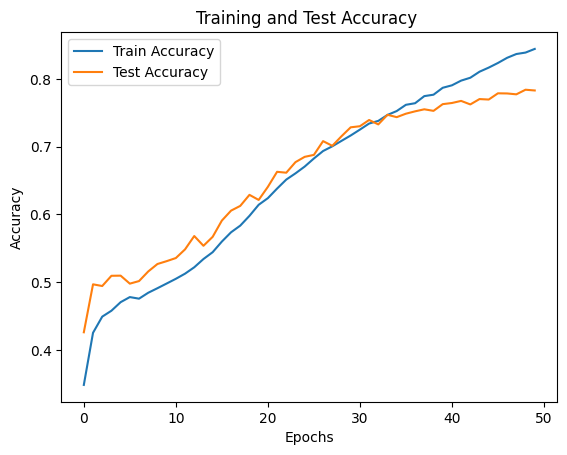

In [ ]:
plt.plot(train_accuracies,label="Train Accuracy")
plt.plot(test_accuracies,label="Test Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training and Test Accuracy ")
plt.show()

In [ ]:
0

0